# Évaluation rapide de checkpoints (MSE / CSI)
Entrées manuelles : chemins des données, liste de PKL (test), dossier de checkpoints, liste d’epochs.
Calculs : MSE (h, u, v) et CSI (pas de CSI_over) aux horizons 30 min / 3 h / 6 h / 12 h (1 / 6 / 12 / 24 pas).
Charge les poids via `modulus.launch.utils.load_checkpoint` en réutilisant les stats présentes dans le dossier de checkpoints.

In [44]:
import os, json, math
import torch, dgl
import numpy as np
import matplotlib.pyplot as plt
from typing import List
import sys

# Ajouter le repo au PYTHONPATH
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)

from python.create_dgl_dataset import TelemacDataset, TelemacDatasetWithQ
from python.CustomMeshGraphNet import MeshGraphNet
from modulus.launch.utils import load_checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [46]:
# =====================
# Paramètres utilisateur (à adapter)
# =====================

# Graphe de base (DGL) et PKL de test
DATA_DIR = "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Multimesh_8_32.bin"
DYNAMIC_DIR = [ 
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_1_peak_2600_Group_1_peak_2600_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_2_peak_1000_Group_2_peak_1000_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_2_peak_1200_Group_2_peak_1200_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_2_peak_1600_Group_2_peak_1600_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_4_peak_2000_Group_4_peak_2000_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_1_peak_1200_Group_1_peak_1200_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_1_peak_2400_Group_1_peak_2400_0_35-64_interpolated.pkl",
    "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Group_3_peak_3400_Group_3_peak_3400_0_35-64_interpolated.pkl",
]

# Activer Q exogène
USE_Q_FEATURE = True
HYDRO_DIR = [
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_1_peak_2600.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_2_peak_1000.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_2_peak_1200.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_2_peak_1600.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_4_peak_2000.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_1_peak_1200.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_1_peak_2400.liq',
    '/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_3_peak_3400.liq',
]
DT_SECONDS = 1800.0

# Dossier checkpoints (contient node_stats.json / edge_stats.json + checkpoint.*.pt)
CKPT_DIR = "/work/m24046/m24046mrcr/paper/Experience10/Seed0/"
CHECKPOINT_EPOCHS = np.arange(600,900,10)#[600,650,700,750,800]  # epochs à évaluer (ex: 0, 40, 80, ...)

# Paramètres modèle (cohérents avec l'entraînement)
NUM_INPUT_FEATURES = 10 if USE_Q_FEATURE else 9
NUM_EDGE_FEATURES = 3
NUM_OUTPUT_FEATURES = 3
MP_LAYERS = 10
DO_CONCAT_TRICK = True
NUM_PROCESSOR_CHECKPOINT_SEGMENTS = 0

# Horizons (en pas de 30 min)
HORIZONS_STEPS = [6,12,24]#, 24]   # 30 min, 3h, 6h, 12h

# Nombre de séquences à évaluer (prend les premières)
MAX_SEQUENCES = 205

# Seuil CSI
THRESHOLD_M = 0.05



In [47]:
import pickle as pkl
with open(DYNAMIC_DIR[0], 'rb') as f:
    data = pkl.load(f)
print(len(data))

30


In [48]:
# =====================
# Fonctions utilitaires
# =====================
def build_model():
    return MeshGraphNet(
        NUM_INPUT_FEATURES,
        NUM_EDGE_FEATURES,
        NUM_OUTPUT_FEATURES,
        processor_size=MP_LAYERS,
        hidden_dim_processor=64,
        hidden_dim_node_encoder=64,
        hidden_dim_edge_encoder=64,
        hidden_dim_node_decoder=64,
        do_concat_trick=DO_CONCAT_TRICK,
        num_processor_checkpoint_segments=NUM_PROCESSOR_CHECKPOINT_SEGMENTS,
    )

def load_model_checkpoint(model, ckpt_dir, epoch):
    # charge le checkpoint demandé (dernier si epoch=None)
    load_checkpoint(ckpt_dir, models=model, device=device, epoch=epoch)
    model.to(device)
    model.eval()
    return model

def build_dataset(sequence_length, overlap=1, split="test"):
    if USE_Q_FEATURE:
        if len(HYDRO_DIR) == 0:
            raise ValueError("USE_Q_FEATURE=True mais HYDRO_DIR est vide.")
        if len(HYDRO_DIR) != len(DYNAMIC_DIR):
            raise ValueError(f"HYDRO_DIR ({len(HYDRO_DIR)}) et DYNAMIC_DIR ({len(DYNAMIC_DIR)}) doivent avoir la même longueur.")
        ds = TelemacDatasetWithQ(
            name=f"eval_{split}",
            data_dir=DATA_DIR,
            dynamic_data_files=DYNAMIC_DIR,
            hydro_data_files=HYDRO_DIR,
            split=split,
            ckpt_path=CKPT_DIR,
            normalize=True,
            sequence_length=sequence_length,
            overlap=overlap,
            dt_seconds=DT_SECONDS,
        )
    else:
        ds = TelemacDataset(
            name=f"eval_{split}",
            data_dir=DATA_DIR,
            dynamic_data_files=DYNAMIC_DIR,
            split=split,
            ckpt_path=CKPT_DIR,
            normalize=True,
            sequence_length=sequence_length,
            overlap=overlap,
        )
    return ds

def _denorm(xn, mean, std):
    return xn * std + mean

def _renorm(x, mean, std):
    return (x - mean) / (std + 1e-12)

def csi_from_binary(pred_mask, gt_mask):
    tp = np.logical_and(pred_mask, gt_mask).sum()
    fp = np.logical_and(pred_mask, ~gt_mask).sum()
    fn = np.logical_and(~pred_mask, gt_mask).sum()
    denom = tp + fp + fn
    return float(tp / denom) if denom > 0 else math.nan

def evaluate_model(model, ds, horizons_steps, max_sequences=10, threshold=0.05):
    stats = ds.node_stats
    dyn_start = ds.base_graph.ndata['static'].shape[1]
    dyn_len = 4 if USE_Q_FEATURE else 3

    mx = torch.tensor([stats['h'].item(), stats['u'].item(), stats['v'].item()], device=device)
    sx = torch.tensor([stats['h_std'].item(), stats['u_std'].item(), stats['v_std'].item()], device=device)
    dy_mean = torch.tensor([stats['delta_h'].item(), stats['delta_u'].item(), stats['delta_v'].item()], device=device)
    dy_std  = torch.tensor([stats['delta_h_std'].item(), stats['delta_u_std'].item(), stats['delta_v_std'].item()], device=device)

    agg = {h: {"mse": [], "csi": []} for h in horizons_steps}
    nseq = min(max_sequences, len(ds))
    max_h = max(horizons_steps)

    for idx in range(nseq):
        graphs = ds[idx]
        if len(graphs) <= max_h:
            continue

        g = graphs[0].to(device)
        static_part = g.ndata['x'][:, :dyn_start]
        xn_t_full = g.ndata['x'][:, dyn_start:dyn_start+dyn_len]

        onehot = static_part[:, :4]
        q_mask = (onehot == torch.tensor([0,0,1,0], device=device)).all(dim=1)
        h_mask = (onehot == torch.tensor([0,1,0,0], device=device)).all(dim=1)

        for t in range(max_h):
            with torch.no_grad():
                y_pred_n = model(g.ndata['x'], g.edata['x'], g)

            xn_t = xn_t_full[:, :3]
            x_t = _denorm(xn_t, mx, sx)
            y_pred = _denorm(y_pred_n, dy_mean, dy_std)
            x_t1 = x_t + y_pred

            x_gt_full_n = graphs[t+1].ndata['x'][:, dyn_start:dyn_start+dyn_len].to(device)
            x_gt_n = x_gt_full_n[:, :3]
            x_gt = _denorm(x_gt_n, mx, sx)

            x_t1[q_mask] = x_gt[q_mask]
            x_t1[h_mask, 0:1] = x_gt[h_mask, 0:1]

            step = t+1
            if step in horizons_steps:
                mse = torch.mean((x_t1 - x_gt)**2, dim=0).detach().cpu().numpy()
                h_pred = x_t1[:,0].detach().cpu().numpy()
                h_gt = x_gt[:,0].detach().cpu().numpy()
                csi = csi_from_binary(h_pred >= threshold, h_gt >= threshold)
                agg[step]["mse"].append(mse)
                agg[step]["csi"].append(csi)

            xn_t1 = _renorm(x_t1, mx, sx)
            if USE_Q_FEATURE:
                q_t1_n = x_gt_full_n[:, 3:4]
                xn_t_full = torch.cat([xn_t1, q_t1_n], dim=1)
            else:
                xn_t_full = xn_t1

            g = g.clone()
            g.ndata['x'] = torch.cat([static_part, xn_t_full], dim=1)

    summary = {}
    for h in horizons_steps:
        if len(agg[h]["mse"]) == 0:
            continue
        summary[h] = {
            "mse_mean": np.nanmean(np.stack(agg[h]["mse"], axis=0), axis=0).tolist(),
            "csi_mean": float(np.nanmean(agg[h]["csi"])),
        }
    return summary

def evaluate_checkpoints(epochs: List[int], horizons_steps=[1,6,12,24], max_sequences=10):
    ds = build_dataset(sequence_length=max(horizons_steps)+1, overlap=1, split="test")

    expected_input_features = ds.base_graph.ndata['static'].shape[1] + (4 if USE_Q_FEATURE else 3)
    if NUM_INPUT_FEATURES != expected_input_features:
        raise ValueError(
            f"NUM_INPUT_FEATURES={NUM_INPUT_FEATURES} incompatible avec dataset ({expected_input_features})."
        )

    metrics_per_epoch = {}
    for ep in epochs:
        model = build_model()
        load_model_checkpoint(model, CKPT_DIR, epoch=ep)
        summary = evaluate_model(model, ds, horizons_steps, max_sequences=max_sequences, threshold=THRESHOLD_M)
        metrics_per_epoch[ep] = summary
    return metrics_per_epoch

def plot_curves(metrics, horizons_steps):
    if not metrics:
        print("Pas de résultats")
        return
    epochs = sorted(metrics.keys())
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    for h in horizons_steps:
        csi_vals = [metrics[e].get(h, {}).get('csi_mean', np.nan) for e in epochs]
        axes[0].plot(epochs, csi_vals, marker='o', label=f"h={h}")
        mse_h = [metrics[e].get(h, {}).get('mse_mean', [np.nan])[0] for e in epochs]
        axes[1].plot(epochs, mse_h, marker='o', label=f"h={h}")
    axes[0].set_title("CSI(h) vs epoch")
    axes[1].set_title("MSE(h) vs epoch")
    
    axes[1].set_yscale('log')

    for ax in axes:
        ax.set_xlabel("epoch")
        ax.grid(True, alpha=0.3)
        ax.legend()
    plt.tight_layout(); plt.show()



In [49]:
# =====================
# Lancement de l'éval
# =====================
metrics = evaluate_checkpoints(CHECKPOINT_EPOCHS, horizons_steps=HORIZONS_STEPS, max_sequences=MAX_SEQUENCES)
metrics



[15:01:26 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience10/Seed0/MeshGraphNet.0.600.mdlus to device cuda


Loading normalization statistics...


[15:01:26 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience10/Seed0/checkpoint.0.600.pt to device cuda
[15:01:29 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience10/Seed0/MeshGraphNet.0.610.mdlus to device cuda
[15:01:29 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience10/Seed0/checkpoint.0.610.pt to device cuda
[15:01:32 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience10/Seed0/MeshGraphNet.0.620.mdlus to device cuda
[15:01:32 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience10/Seed0/checkpoint.0.620.pt to device cuda
[15:01:35 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience10/Seed0/MeshGraphNet.0.630.mdlus to device cuda
[15:01:35 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience10/Seed0/checkpoint.0.630.pt to device cud

{600: {6: {'mse_mean': [0.003574577858671546,
    0.0022950617130845785,
    0.0009217487531714141],
   'csi_mean': 0.941041630629419},
  12: {'mse_mean': [0.013977297581732273,
    0.007310338784009218,
    0.0032878248021006584],
   'csi_mean': 0.8839108871038139},
  24: {'mse_mean': [0.019702894613146782,
    0.0069252667017281055,
    0.002795850159600377],
   'csi_mean': 0.8402215970464002}},
 610: {6: {'mse_mean': [0.0033312244340777397,
    0.0020395610481500626,
    0.0008156468393281102],
   'csi_mean': 0.9416144760096943},
  12: {'mse_mean': [0.013683111406862736,
    0.006976963486522436,
    0.0030597473960369825],
   'csi_mean': 0.8896904052749014},
  24: {'mse_mean': [0.017974775284528732,
    0.006709624081850052,
    0.002700926037505269],
   'csi_mean': 0.8321304754872818}},
 620: {6: {'mse_mean': [0.003092878730967641,
    0.0020459035877138376,
    0.0008267438388429582],
   'csi_mean': 0.943937200445215},
  12: {'mse_mean': [0.012445706874132156,
    0.0061636371538

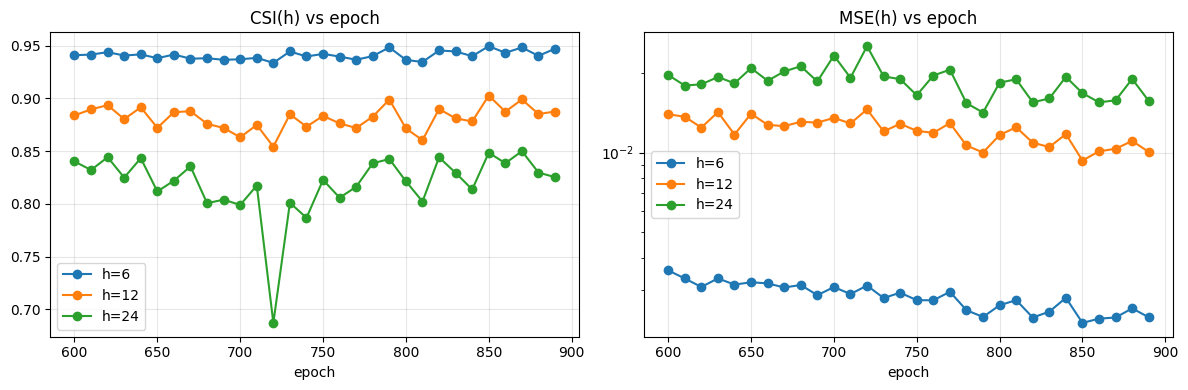

In [50]:
plot_curves(metrics, HORIZONS_STEPS)



In [51]:
import pandas as pd

rows = []
for ep, res in metrics.items():
    for h, vals in res.items():
        mse_mean = vals.get("mse_mean", [np.nan, np.nan, np.nan])
        rows.append({
            "epoch": ep,
            "horizon_steps": h,
            "mse_h": mse_mean[0],
            "mse_u": mse_mean[1],
            "mse_v": mse_mean[2],
            "csi": vals.get("csi_mean", np.nan),
        })

df = pd.DataFrame(rows)
csv_path = "/work/m24046/m24046mrcr/paper/Experience10.csv"  # adapte le chemin si besoin
df.to_csv(csv_path, index=False)
df



,epoch,horizon_steps,mse_h,mse_u,mse_v,csi
0,600,6,0.003575,0.002295,0.000922,0.941042
1,600,12,0.013977,0.007310,0.003288,0.883911
2,600,24,0.019703,0.006925,0.002796,0.840222
3,610,6,0.003331,0.002040,0.000816,0.941614
4,610,12,0.013683,0.006977,0.003060,0.889690
...,...,...,...,...,...,...
85,880,12,0.011077,0.004978,0.002404,0.885271
86,880,24,0.019035,0.006328,0.002320,0.829737
87,890,6,0.002373,0.001483,0.000628,0.947218
88,890,12,0.010060,0.005042,0.002323,0.887580
